In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Simple Linear Regression


### Data Collection

In [61]:
auto = pd.read_csv(r'datasets/auto.csv') #importing data from an excel filea

In [62]:
auto.head(10)

,symboling,normalized losses,make,fuel type,aspiration,doors,style,wheels,engine location,wheel base,...,engine size,fuel system,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


In [63]:
auto.head(10)

,symboling,normalized losses,make,fuel type,aspiration,doors,style,wheels,engine location,wheel base,...,engine size,fuel system,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


In [64]:
auto.columns

Index(['symboling', 'normalized losses', 'make', 'fuel type', 'aspiration',
       'doors', 'style', 'wheels', 'engine location', 'wheel base', 'length',
       'width', 'height', 'curb weight', 'engine type', 'cylinders',
       'engine size', 'fuel system', 'bore', 'stroke', 'compression ratio',
       'horsepower', 'peak rpm', 'city mpg', 'highway mpg', 'price'],
      dtype='object')

### EDA & Preprocessing

In [19]:
auto.drop(['symboling', 'normalized losses'], axis=1,inplace=True) #deleting columns in pandas

In [20]:
auto.head(10)

,make,fuel type,aspiration,doors,style,wheels,engine location,wheel base,length,width,...,engine size,fuel system,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


In [21]:
auto.columns #return column names of df.

Index(['make', 'fuel type', 'aspiration', 'doors', 'style', 'wheels',
       'engine location', 'wheel base', 'length', 'width', 'height',
       'curb weight', 'engine type', 'cylinders', 'engine size', 'fuel system',
       'bore', 'stroke', 'compression ratio', 'horsepower', 'peak rpm',
       'city mpg', 'highway mpg', 'price'],
      dtype='object')

In [22]:
auto['fuel type'].unique()

array(['gas', 'diesel'], dtype=object)

In [23]:
auto['horsepower'].unique()

array(['111', '154', '102', '115', '110', '140', '160', '101', '121',
       '182', '48', '70', '68', '88', '145', '58', '76', '60', '86',
       '100', '78', '90', '176', '262', '135', '84', '64', '120', '72',
       '123', '155', '184', '175', '116', '69', '55', '97', '152', '200',
       '95', '142', '143', '207', '288', '?', '73', '82', '94', '62',
       '56', '112', '92', '161', '156', '52', '85', '114', '162', '134',
       '106'], dtype=object)

In [24]:
auto_1 = auto[['horsepower', 'price']]

In [25]:
auto_1.head(10)

,horsepower,price
0,111,13495
1,111,16500
2,154,16500
3,102,13950
4,115,17450
5,110,15250
6,110,17710
7,110,18920
8,140,23875
9,160,?


In [26]:
auto_1.replace('?', np.nan,inplace=True) #replace values inside a df.

C:\Users\Arun\AppData\Local\Temp\ipykernel_33892\1187171997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  auto_1.replace('?', np.nan,inplace=True) #replace values inside a df.


In [27]:
auto_1.tail(10) #head(), tail() functions to get the top and bottom n records or samples.

,horsepower,price
195,114,13415
196,114,15985
197,114,16515
198,162,18420
199,162,18950
200,114,16845
201,160,19045
202,134,21485
203,106,22470
204,114,22625


In [28]:
auto_1.dtypes

horsepower    object
price         object
dtype: object

In [29]:
auto_1['price'].unique()

array(['13495', '16500', '13950', '17450', '15250', '17710', '18920',
       '23875', nan, '16430', '16925', '20970', '21105', '24565', '30760',
       '41315', '36880', '5151', '6295', '6575', '5572', '6377', '7957',
       '6229', '6692', '7609', '8558', '8921', '12964', '6479', '6855',
       '5399', '6529', '7129', '7295', '7895', '9095', '8845', '10295',
       '12945', '10345', '6785', '11048', '32250', '35550', '36000',
       '5195', '6095', '6795', '6695', '7395', '10945', '11845', '13645',
       '15645', '8495', '10595', '10245', '10795', '11245', '18280',
       '18344', '25552', '28248', '28176', '31600', '34184', '35056',
       '40960', '45400', '16503', '5389', '6189', '6669', '7689', '9959',
       '8499', '12629', '14869', '14489', '6989', '8189', '9279', '5499',
       '7099', '6649', '6849', '7349', '7299', '7799', '7499', '7999',
       '8249', '8949', '9549', '13499', '14399', '17199', '19699',
       '18399', '11900', '13200', '12440', '13860', '15580', '16900',


In [30]:
auto_1.dtypes #display the datatypes of the table

horsepower    object
price         object
dtype: object

In [31]:
auto_1.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   horsepower  203 non-null    object
 1   price       201 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB


In [32]:
auto_1.describe() 

,horsepower,price
count,203,201
unique,59,186
top,68,8921
freq,19,2


In [33]:
auto_1.shape #tuple of #of rows and columns 

(205, 2)

In [34]:
#convert the datatype of the column - typecasting

auto_1['price'] = auto_1['price'].astype('float64')
auto_1['horsepower'] = auto_1['horsepower'].astype('float64')

C:\Users\Arun\AppData\Local\Temp\ipykernel_33892\4161427274.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  auto_1['price'] = auto_1['price'].astype('float64')
C:\Users\Arun\AppData\Local\Temp\ipykernel_33892\4161427274.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  auto_1['horsepower'] = auto_1['horsepower'].astype('float64')


In [35]:
auto_1.dtypes

horsepower    float64
price         float64
dtype: object

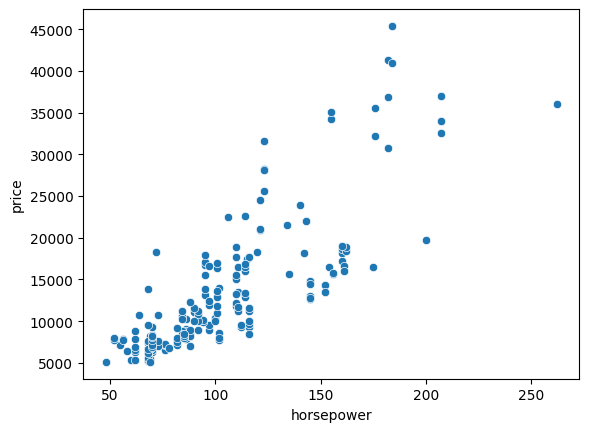

In [36]:
sns.scatterplot(x=auto_1['horsepower'], y=auto_1['price'])
plt.show()

#Observations:
#1. Identified strong - linear relationship b/w the hp and price. OK to model.

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [38]:
auto_1 = auto_1.dropna().reset_index() #remove the null records from the df

In [39]:
auto_1.head(10)

,index,horsepower,price
0,0,111.0,13495.0
1,1,111.0,16500.0
2,2,154.0,16500.0
3,3,102.0,13950.0
4,4,115.0,17450.0
5,5,110.0,15250.0
6,6,110.0,17710.0
7,7,110.0,18920.0
8,8,140.0,23875.0
9,10,101.0,16430.0


In [40]:
X = np.array(auto_1['horsepower']).reshape(-1, 1)
y = np.array(auto_1['price'])

# .reshape(-1, 1)

In [41]:
X

array([[111.],
       [111.],
       [154.],
       [102.],
       [115.],
       [110.],
       [110.],
       [110.],
       [140.],
       [101.],
       [101.],
       [121.],
       [121.],
       [121.],
       [182.],
       [182.],
       [182.],
       [ 48.],
       [ 70.],
       [ 70.],
       [ 68.],
       [ 68.],
       [102.],
       [ 68.],
       [ 68.],
       [ 68.],
       [102.],
       [ 88.],
       [145.],
       [ 58.],
       [ 76.],
       [ 60.],
       [ 76.],
       [ 76.],
       [ 76.],
       [ 76.],
       [ 86.],
       [ 86.],
       [ 86.],
       [ 86.],
       [101.],
       [100.],
       [ 78.],
       [ 90.],
       [176.],
       [176.],
       [262.],
       [ 68.],
       [ 68.],
       [ 68.],
       [ 68.],
       [ 68.],
       [101.],
       [101.],
       [101.],
       [135.],
       [ 84.],
       [ 84.],
       [ 84.],
       [ 84.],
       [ 64.],
       [ 84.],
       [120.],
       [ 72.],
       [123.],
       [123.],
       [12

In [42]:
#Splitting our dependent and independent varibles into train/test split.

X_train, X_test, y_train, y_test = train_test_split(X,y, 
                                                    train_size=0.8, 
                                                    test_size=0.20
                                                    )

### Model Building

In [43]:
reg = LinearRegression() #initializing a Linear Regression Class

In [44]:
reg_fit_main = reg.fit(X_train, y_train) #training the model

In [45]:
reg.coef_ #model coefficients or parameters

array([165.93538814])

In [46]:
reg.intercept_ #model intercept

-3982.971408358386

### Model Evaluation

In [47]:
r_square = reg_fit_main.score(X_train, y_train)
print('Model R-Squared:', r_square)

Model R-Squared: 0.6331396077276628


In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [49]:
y_predicted = reg_fit_main.predict(X_test)

In [50]:

print("Model Evalutation Metics")
print("=========================")
print("MSE: ", round(mean_squared_error(y_test, y_predicted),2))
print("MAE: ", round(mean_absolute_error(y_test, y_predicted),2))
print("MAPE: ", round(mean_absolute_percentage_error(y_test, y_predicted),2))

Model Evalutation Metics
MSE:  23070240.83
MAE:  3291.14
MAPE:  0.21


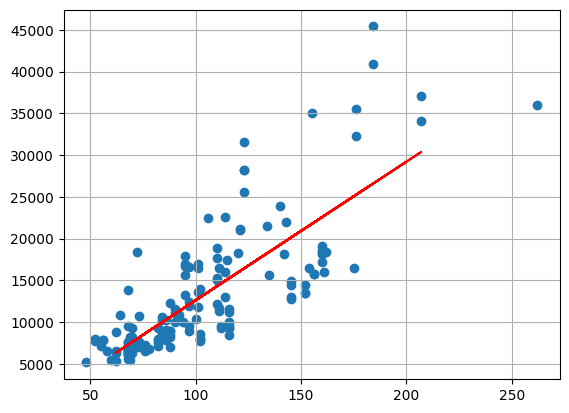

In [51]:
plt.scatter(X_train,y_train)
plt.plot(X_test, y_predicted, 'r')
plt.grid(True)
plt.show()

## Multiple Linear Regression Model

In [53]:
auto.head(10)

,symboling,normalized losses,make,fuel type,aspiration,doors,style,wheels,engine location,wheel base,...,engine size,fuel system,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


### EDA & Pre-Processing

In [65]:
#programming rules
#1.longer detailed variable names >> shorter names
#2.comments are part of part of the code not optional
#3.Function to do exactly one thing.

auto.replace('?', 0,inplace=True) #replacing the values in the df
auto.drop(['normalized losses'], axis=1,inplace=True) #drop a col in the df ; 0 - row index, 1 - col index ; inplace=True - modifying the original df

df_car_new = auto.copy(deep=True) #creating a copy of the df


#encoding cols with two category variable to binary

df_car_new['fuel type'] = df_car_new['fuel type'].map({'gas':1, 'diesel':0}) #encoding fuel type to binary
df_car_new['aspiration'] = df_car_new['aspiration'].map({'std':1, 'turbo':0})
df_car_new['doors'] = df_car_new['doors'].map({'four':1, 'two':0})

In [66]:
#One - hot encoding. 

def getDummies(df, category_cols):
    for col in category_cols:
        dummy_df = pd.get_dummies(df[col], drop_first=True, dtype='int')
        new_col_map = {c: f"{col}_{c}" for c in dummy_df.columns}
        dummy_df.rename(columns=new_col_map,inplace=True)
        df = pd.concat([df,dummy_df],axis=1)
    df.drop(category_cols,axis=1,inplace=True)
    return df

In [67]:
df_car_new.head(2).to_clipboard(index=False)

In [68]:
encode_cols = ['make', 'fuel system', 'cylinders', 'engine type', 'symboling', 'wheels', 'style'] #cat cols stored insida a list
df_car_1 = getDummies(df=df_car_new, category_cols=encode_cols) #return the df with numerical cols

df_car_1['price'] = df_car_new['price'].copy(deep=True)
df_car_1['engine location'] = df_car_1['engine location'].map({'front':1, 'rear':0})


# loop which casts the col dtype to float

for col in df_car_1.select_dtypes('object').columns:
    df_car_1[col] = df_car_1[col].astype(float)

In [69]:
df_car_1

,fuel type,aspiration,doors,engine location,wheel base,length,width,height,curb weight,engine size,...,symboling_0,symboling_1,symboling_2,symboling_3,wheels_fwd,wheels_rwd,style_hardtop,style_hatchback,style_sedan,style_wagon
0,1,1,0.0,1,88.6,168.8,64.1,48.8,2548,130,...,0,0,0,1,0,1,0,0,0,0
1,1,1,0.0,1,88.6,168.8,64.1,48.8,2548,130,...,0,0,0,1,0,1,0,0,0,0
2,1,1,0.0,1,94.5,171.2,65.5,52.4,2823,152,...,0,1,0,0,0,1,0,1,0,0
3,1,1,1.0,1,99.8,176.6,66.2,54.3,2337,109,...,0,0,1,0,1,0,0,0,1,0
4,1,1,1.0,1,99.4,176.6,66.4,54.3,2824,136,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1,1,1.0,1,109.1,188.8,68.9,55.5,2952,141,...,0,0,0,0,0,1,0,0,1,0
201,1,0,1.0,1,109.1,188.8,68.8,55.5,3049,141,...,0,0,0,0,0,1,0,0,1,0
202,1,1,1.0,1,109.1,188.8,68.9,55.5,3012,173,...,0,0,0,0,0,1,0,0,1,0
203,0,0,1.0,1,109.1,188.8,68.9,55.5,3217,145,...,0,0,0,0,0,1,0,0,1,0


In [70]:
df_car_1.columns

Index(['fuel type', 'aspiration', 'doors', 'engine location', 'wheel base',
       'length', 'width', 'height', 'curb weight', 'engine size', 'bore',
       'stroke', 'compression ratio', 'horsepower', 'peak rpm', 'city mpg',
       'highway mpg', 'price', 'make_audi', 'make_bmw', 'make_chevrolet',
       'make_dodge', 'make_honda', 'make_isuzu', 'make_jaguar', 'make_mazda',
       'make_mercedes-benz', 'make_mercury', 'make_mitsubishi', 'make_nissan',
       'make_peugot', 'make_plymouth', 'make_porsche', 'make_renault',
       'make_saab', 'make_subaru', 'make_toyota', 'make_volkswagen',
       'make_volvo', 'fuel system_2bbl', 'fuel system_4bbl', 'fuel system_idi',
       'fuel system_mfi', 'fuel system_mpfi', 'fuel system_spdi',
       'fuel system_spfi', 'cylinders_five', 'cylinders_four', 'cylinders_six',
       'cylinders_three', 'cylinders_twelve', 'cylinders_two',
       'engine type_dohcv', 'engine type_l', 'engine type_ohc',
       'engine type_ohcf', 'engine type_ohcv', 'en

In [71]:
# filtering numericals cols for bi-variate analysis

num_vars = [
       'wheel base',
       'length', 'width', 'height', 'curb weight', 
       'engine size', 'bore',
       'stroke', 'compression ratio', 
       'horsepower', 'peak rpm', 'city mpg',
       'highway mpg', 'price'
       ]

In [72]:
df_car_1[num_vars]

,wheel base,length,width,height,curb weight,engine size,bore,stroke,compression ratio,horsepower,peak rpm,city mpg,highway mpg,price
0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


<Figure size 1600x1600 with 0 Axes>

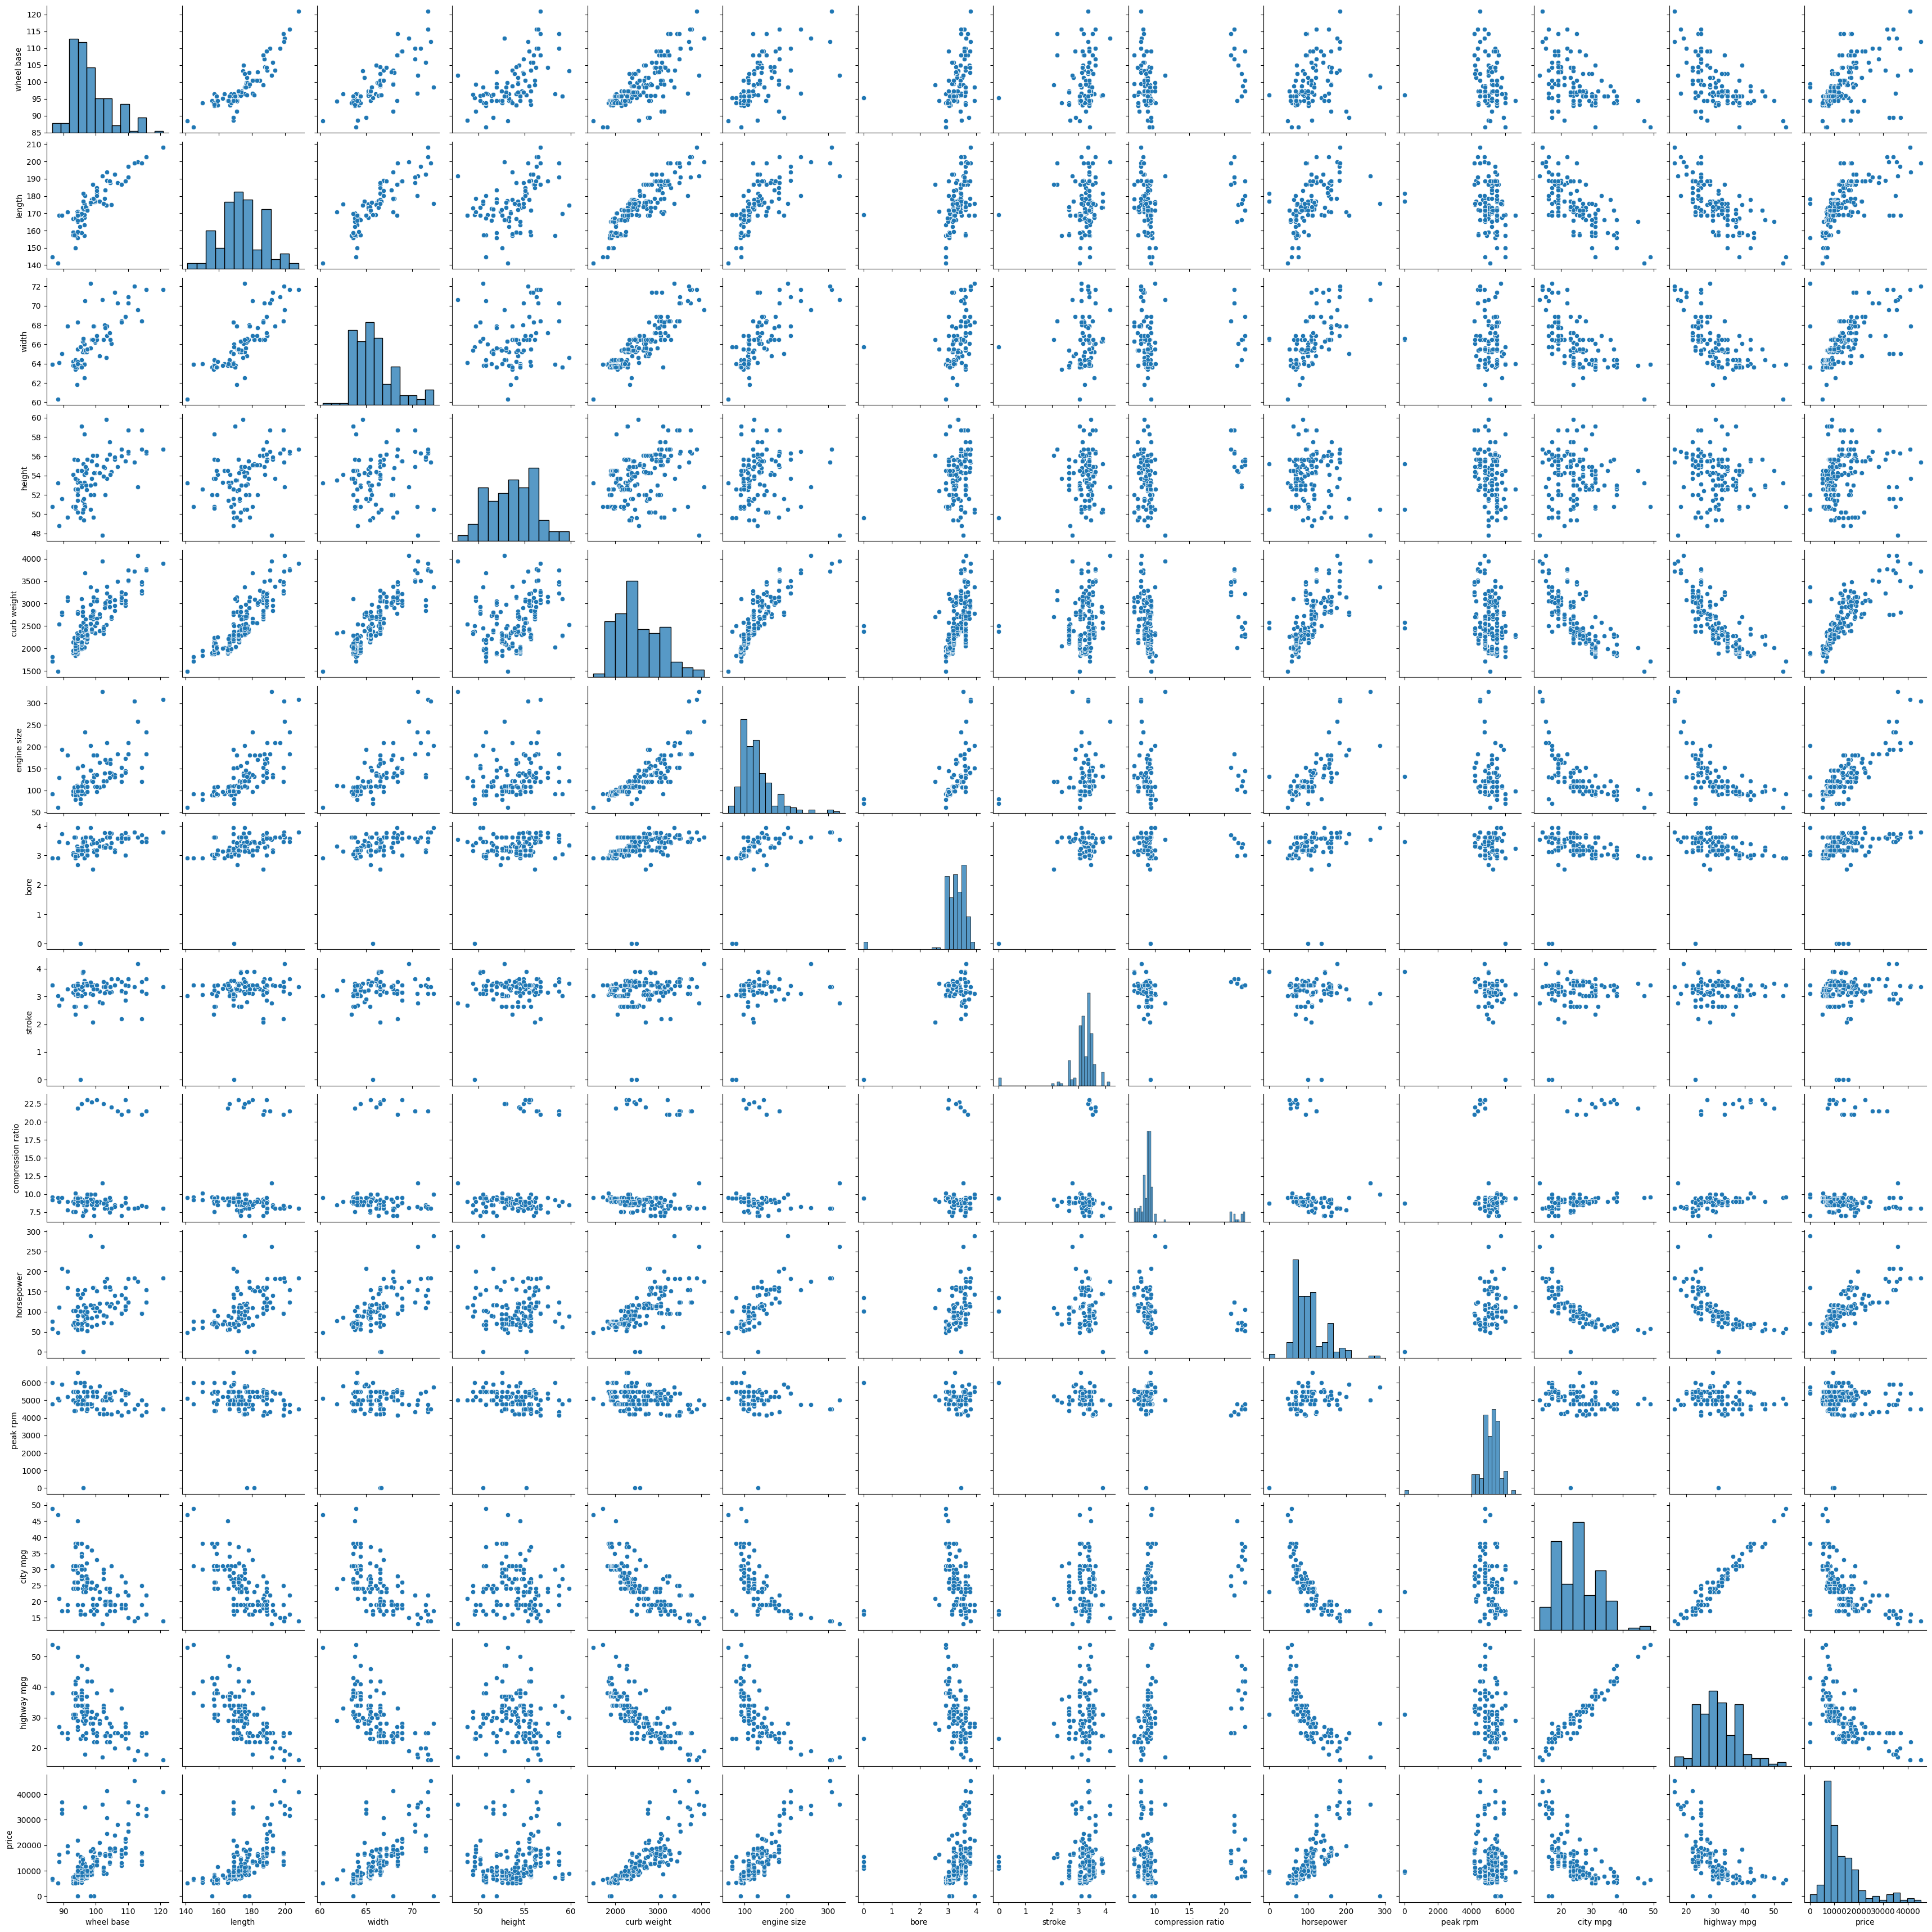

In [73]:
plt.figure(figsize=(16,16))
sns.pairplot(df_car_1[num_vars]) #pairplot for bi-variate analysis
plt.show()

In [74]:
df_car_1.columns

Index(['fuel type', 'aspiration', 'doors', 'engine location', 'wheel base',
       'length', 'width', 'height', 'curb weight', 'engine size', 'bore',
       'stroke', 'compression ratio', 'horsepower', 'peak rpm', 'city mpg',
       'highway mpg', 'price', 'make_audi', 'make_bmw', 'make_chevrolet',
       'make_dodge', 'make_honda', 'make_isuzu', 'make_jaguar', 'make_mazda',
       'make_mercedes-benz', 'make_mercury', 'make_mitsubishi', 'make_nissan',
       'make_peugot', 'make_plymouth', 'make_porsche', 'make_renault',
       'make_saab', 'make_subaru', 'make_toyota', 'make_volkswagen',
       'make_volvo', 'fuel system_2bbl', 'fuel system_4bbl', 'fuel system_idi',
       'fuel system_mfi', 'fuel system_mpfi', 'fuel system_spdi',
       'fuel system_spfi', 'cylinders_five', 'cylinders_four', 'cylinders_six',
       'cylinders_three', 'cylinders_twelve', 'cylinders_two',
       'engine type_dohcv', 'engine type_l', 'engine type_ohc',
       'engine type_ohcf', 'engine type_ohcv', 'en

In [75]:
df_car_1['price'].corr(df_car_1['highway mpg'])

-0.6876750740856993

In [76]:
#function to generate corelation matrix of the num cols

df_car_1.corr().head(50)

,fuel type,aspiration,doors,engine location,wheel base,length,width,height,curb weight,engine size,...,symboling_0,symboling_1,symboling_2,symboling_3,wheels_fwd,wheels_rwd,style_hardtop,style_hatchback,style_sedan,style_wagon
fuel type,1.000000,0.401397,-0.181675,-0.040070,-0.308346,-0.212679,-0.233880,-0.284631,-0.217275,-0.069594,...,-0.156438,0.159302,0.005524,0.128056,0.090342,-0.122035,-0.018635,0.202093,-0.185623,-0.028183
aspiration,0.401397,1.000000,-0.046350,-0.057191,-0.257611,-0.234539,-0.300567,-0.087311,-0.324902,-0.108217,...,0.029547,0.079080,0.131943,-0.117276,0.145681,-0.112470,0.029074,-0.009786,-0.017111,-0.018908
doors,-0.181675,-0.046350,1.000000,0.138613,0.445696,0.393593,0.202072,0.547651,0.195683,0.017519,...,0.464914,-0.220685,-0.217149,-0.443285,0.034894,-0.075486,-0.229237,-0.612202,0.521878,0.331133
engine location,-0.040070,-0.057191,0.138613,1.000000,0.187790,0.050989,0.051698,0.106234,-0.050468,-0.196826,...,0.084915,0.072877,0.052413,-0.312905,0.144799,-0.158772,-0.394978,0.087754,0.114369,0.045417
wheel base,-0.308346,-0.257611,0.445696,0.187790,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,...,0.274072,-0.283085,-0.180357,-0.244038,-0.460355,0.498830,-0.008608,-0.386094,0.291086,0.210899
length,-0.212679,-0.234539,0.393593,0.050989,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,...,0.248857,-0.360253,-0.171755,-0.028868,-0.508714,0.538370,0.047292,-0.436269,0.269647,0.219683
width,-0.233880,-0.300567,0.202072,0.051698,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,...,0.106804,-0.240230,-0.163606,0.043742,-0.472116,0.511149,0.066360,-0.222308,0.154637,0.060639
height,-0.284631,-0.087311,0.547651,0.106234,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,...,0.301354,-0.223722,-0.035818,-0.415848,-0.100273,0.039814,-0.072328,-0.477476,0.235863,0.459148
curb weight,-0.217275,-0.324902,0.195683,-0.050468,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,...,0.205350,-0.377306,-0.183255,0.121437,-0.666039,0.669987,0.098956,-0.287501,0.099425,0.164075
engine size,-0.069594,-0.108217,0.017519,-0.196826,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,...,0.130234,-0.251389,-0.137191,0.134557,-0.518391,0.565509,0.239363,-0.216805,0.088459,-0.027518


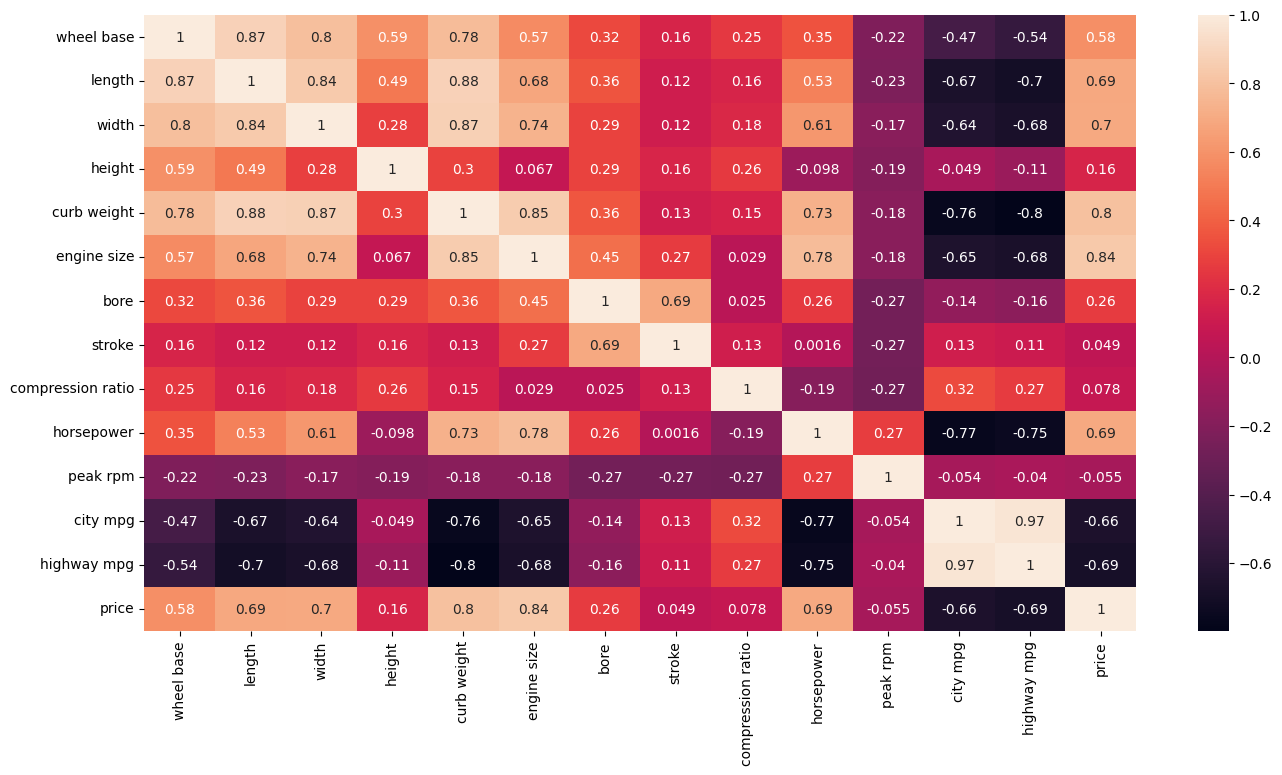

In [77]:
plt.figure(figsize=(16,8))
sns.heatmap(df_car_1[num_vars].corr(), annot=True)
plt.show()

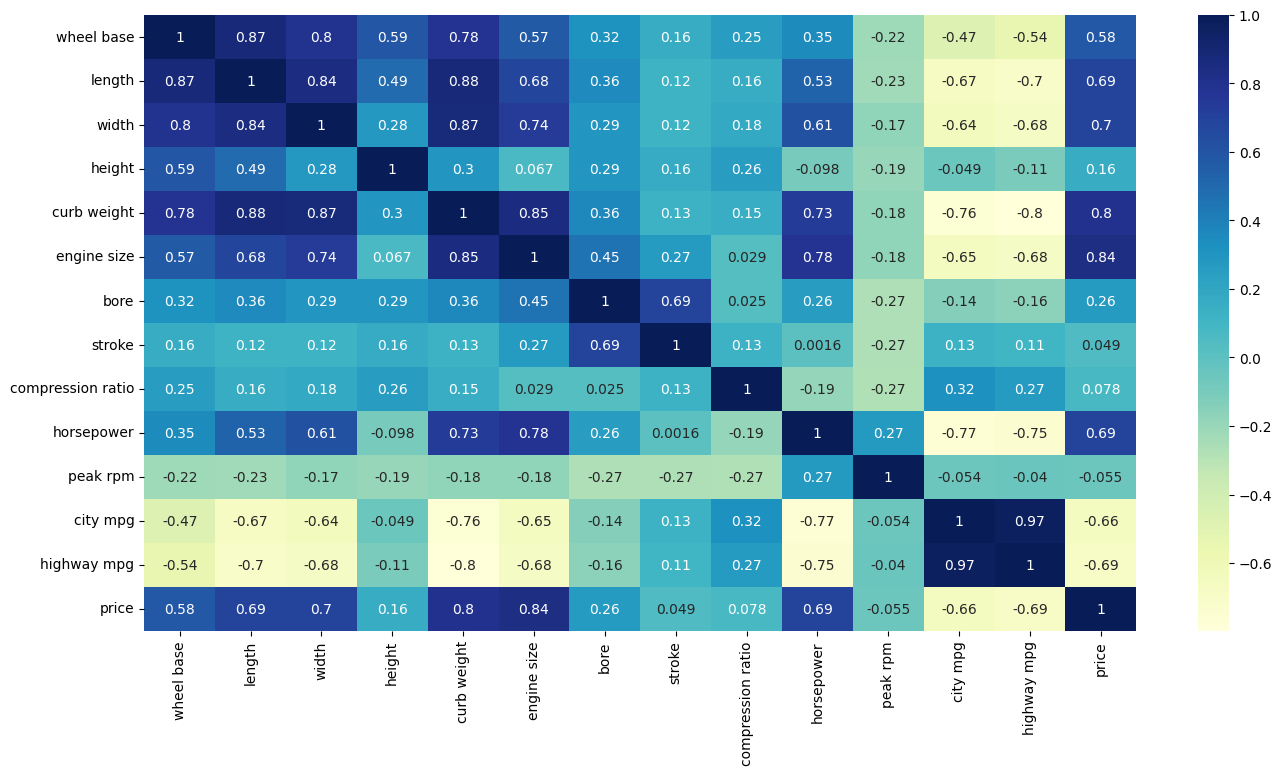

In [78]:
plt.figure(figsize=(16,8))
sns.heatmap(df_car_1[num_vars].corr(), annot=True, cmap='YlGnBu')
plt.show()

In [79]:
#co-relations w.r.t price

corr_matrix = df_car_1.corr()['price']
corr_matrix = pd.DataFrame(corr_matrix).reset_index()
corr_matrix.sort_values(by='price', ascending=False).head(20) #function to sort values of a df

,index,price
17,price,1.000000
9,engine size,0.838097
8,curb weight,0.799773
6,width,0.695654
13,horsepower,0.691288
5,length,0.685019
64,wheels_rwd,0.623644
4,wheel base,0.578804
26,make_mercedes-benz,0.517527
43,fuel system_mpfi,0.488836


### Model Iteration - 1

In [80]:
var_1 = corr_matrix.sort_values(by='price', ascending=False).head(20)['index'].unique() #selecting the top 10 variables


In [81]:
var_1

array(['price', 'engine size', 'curb weight', 'width', 'horsepower',
       'length', 'wheels_rwd', 'wheel base', 'make_mercedes-benz',
       'fuel system_mpfi', 'cylinders_six', 'engine type_ohcv',
       'make_bmw', 'make_jaguar', 'bore', 'make_porsche', 'style_hardtop',
       'cylinders_five', 'symboling_3', 'cylinders_twelve'], dtype=object)

In [82]:
df_car_itr_1 = df_car_1[var_1]

In [79]:
df_car_itr_1

,price,engine size,curb weight,width,horsepower,length,wheels_rwd,wheel base,make_mercedes-benz,fuel system_mpfi,cylinders_six,engine type_ohcv,make_bmw,make_jaguar,bore,make_porsche,style_hardtop,cylinders_five,symboling_3,cylinders_twelve
0,13495.0,130,2548,64.1,111.0,168.8,1,88.6,0,1,0,0,0,0,3.47,0,0,0,1,0
1,16500.0,130,2548,64.1,111.0,168.8,1,88.6,0,1,0,0,0,0,3.47,0,0,0,1,0
2,16500.0,152,2823,65.5,154.0,171.2,1,94.5,0,1,1,1,0,0,2.68,0,0,0,0,0
3,13950.0,109,2337,66.2,102.0,176.6,0,99.8,0,1,0,0,0,0,3.19,0,0,0,0,0
4,17450.0,136,2824,66.4,115.0,176.6,0,99.4,0,1,0,0,0,0,3.19,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,16845.0,141,2952,68.9,114.0,188.8,1,109.1,0,1,0,0,0,0,3.78,0,0,0,0,0
201,19045.0,141,3049,68.8,160.0,188.8,1,109.1,0,1,0,0,0,0,3.78,0,0,0,0,0
202,21485.0,173,3012,68.9,134.0,188.8,1,109.1,0,1,1,1,0,0,3.58,0,0,0,0,0
203,22470.0,145,3217,68.9,106.0,188.8,1,109.1,0,0,1,0,0,0,3.01,0,0,0,0,0


In [83]:
y = df_car_itr_1.pop('price') #Seperate the target from the df

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_car_itr_1, y)

In [83]:
y_train

22      6377.0
112    16900.0
73     40960.0
89      5499.0
119     7957.0
        ...   
142     7775.0
14     24565.0
172    17669.0
202    21485.0
187     9495.0
Name: price, Length: 153, dtype: float64

In [85]:
#Using statsmodels' module for regession 

import statsmodels.api as sm

x_train_sm_1 = sm.add_constant(X_train)
lr_1 = sm.OLS(y_train, x_train_sm_1)
lr_model_1 = lr_1.fit()
print(lr_model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     35.65
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           6.74e-43
Time:                        19:44:27   Log-Likelihood:                -1450.4
No. Observations:                 153   AIC:                             2941.
Df Residuals:                     133   BIC:                             3001.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -1.494e+04   1.94

In [87]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def getVIF(df):

    vif = pd.DataFrame()
    vif['Features'] = df.columns
    vif['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)

    return vif

In [88]:
getVIF(X_train)

,Features,VIF
6,wheel base,2467.93
4,length,2078.29
2,width,2005.60
1,curb weight,482.14
0,engine size,177.20
13,bore,71.70
3,horsepower,38.81
5,wheels_rwd,4.76
9,cylinders_six,3.79
10,engine type_ohcv,3.69


### Model Iteration - 2

In [25]:
var_2 = ['price', 'engine size', 'horsepower',
        'wheels(rwd)','make(mercedes-benz)',
       'fuel system(mpfi)', 'cylinders(six)', 'engine type(ohcv)',
       'make(bmw)', 'make(jaguar)', 'bore', 'make(porsche)',
       'style(hardtop)', 'cylinders(five)', 'symboling(3)',
       'cylinders(twelve)']

In [24]:
df_car_1.columns

Index(['fuel type', 'aspiration', 'doors', 'engine location', 'wheel base',
       'length', 'width', 'height', 'curb weight', 'engine size', 'bore',
       'stroke', 'compression ratio', 'horsepower', 'peak rpm', 'city mpg',
       'highway mpg', 'price', 'make(audi)', 'make(bmw)', 'make(chevrolet)',
       'make(dodge)', 'make(honda)', 'make(isuzu)', 'make(jaguar)',
       'make(mazda)', 'make(mercedes-benz)', 'make(mercury)',
       'make(mitsubishi)', 'make(nissan)', 'make(peugot)', 'make(plymouth)',
       'make(porsche)', 'make(renault)', 'make(saab)', 'make(subaru)',
       'make(toyota)', 'make(volkswagen)', 'make(volvo)', 'fuel system(2bbl)',
       'fuel system(4bbl)', 'fuel system(idi)', 'fuel system(mfi)',
       'fuel system(mpfi)', 'fuel system(spdi)', 'fuel system(spfi)',
       'cylinders(five)', 'cylinders(four)', 'cylinders(six)',
       'cylinders(three)', 'cylinders(twelve)', 'cylinders(two)',
       'engine type(dohcv)', 'engine type(l)', 'engine type(ohc)',
      

In [26]:
df_car_itr_2 = df_car_1[var_2]

y = df_car_itr_2.pop('price')

x_train, x_test, y_train, y_test = train_test_split(df_car_itr_2, y)

x_train_sm_2 = sm.add_constant(x_train)
lr_1 = sm.OLS(y_train, x_train_sm_2)
lr_model_2  = lr_1.fit()
print(lr_model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     49.56
Date:                Fri, 09 May 2025   Prob (F-statistic):           9.83e-48
Time:                        07:44:12   Log-Likelihood:                -1456.0
No. Observations:                 153   AIC:                             2944.
Df Residuals:                     137   BIC:                             2992.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1253.3578   2

In [38]:
from sklearn.metrics import r2_score

X_test_sm = sm.add_constant(x_test)
y_test_pred = lr_model_2.predict(X_test_sm)

r_square = r2_score(y_test_pred, y_test)
print(r_square)


0.4304085640184059


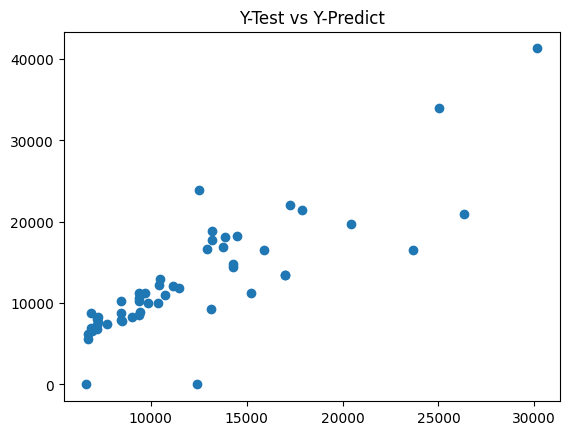

In [40]:
plt.scatter(y_test_pred, y_test)
plt.title('Y-Test vs Y-Predict')
plt.show()

###  Model Iteration - 3

In [ ]:
vars_10 = [

'price', 'engine size', 'curb weight', 'width', 'horsepower',
       'length', 'wheels(rwd)', 'wheel base', 'make(mercedes-benz)',
       'fuel system(mpfi)', 'cylinders(six)', 'engine type(ohcv)',
       'make(bmw)', 'make(jaguar)', 'bore', 'make(porsche)',
       'style(hardtop)', 'cylinders(five)', 'symboling(3)',
       'cylinders(twelve)',
       'highway mpg', 'city mpg', 'cylinders(four)', 'wheels(fwd)',
       'fuel system(2bbl)'
]

In [31]:
df_car_itr_3_temp = df_car_1[vars_10]

In [32]:
df_car_itr_3_temp

,price,engine size,curb weight,width,horsepower,length,wheels(rwd),wheel base,make(mercedes-benz),fuel system(mpfi),...,make(porsche),style(hardtop),cylinders(five),symboling(3),cylinders(twelve),highway mpg,city mpg,cylinders(four),wheels(fwd),fuel system(2bbl)
0,13495.0,130,2548,64.1,111.0,168.8,1,88.6,0,1,...,0,0,0,1,0,27,21,1,0,0
1,16500.0,130,2548,64.1,111.0,168.8,1,88.6,0,1,...,0,0,0,1,0,27,21,1,0,0
2,16500.0,152,2823,65.5,154.0,171.2,1,94.5,0,1,...,0,0,0,0,0,26,19,0,0,0
3,13950.0,109,2337,66.2,102.0,176.6,0,99.8,0,1,...,0,0,0,0,0,30,24,1,1,0
4,17450.0,136,2824,66.4,115.0,176.6,0,99.4,0,1,...,0,0,1,0,0,22,18,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,16845.0,141,2952,68.9,114.0,188.8,1,109.1,0,1,...,0,0,0,0,0,28,23,1,0,0
201,19045.0,141,3049,68.8,160.0,188.8,1,109.1,0,1,...,0,0,0,0,0,25,19,1,0,0
202,21485.0,173,3012,68.9,134.0,188.8,1,109.1,0,1,...,0,0,0,0,0,23,18,0,0,0
203,22470.0,145,3217,68.9,106.0,188.8,1,109.1,0,0,...,0,0,0,0,0,27,26,0,0,0


In [33]:
def remove_highly_correlated(df, threshold=0.6, target_column='price'):
    corr_matrix = df.corr().abs()

    # Create upper triangle matrix of correlations
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Find columns to drop
    to_drop = []
    for column in upper.columns:
        if any(upper[column] > threshold):
            # Don't drop the target column
            if column != target_column:
                to_drop.append(column)

    print(f"Variables dropped due to high correlation (> {threshold}): {to_drop}", end='\n')
    return df.drop(columns=to_drop)

In [35]:
remove_highly_correlated(df_car_itr_3_temp).columns

Variables dropped due to high correlation (> 0.6): ['engine size', 'curb weight', 'width', 'horsepower', 'length', 'wheels(rwd)', 'wheel base', 'highway mpg', 'city mpg', 'cylinders(four)', 'wheels(fwd)', 'fuel system(2bbl)']


Index(['price', 'make(mercedes-benz)', 'fuel system(mpfi)', 'cylinders(six)',
       'engine type(ohcv)', 'make(bmw)', 'make(jaguar)', 'bore',
       'make(porsche)', 'style(hardtop)', 'cylinders(five)', 'symboling(3)',
       'cylinders(twelve)'],
      dtype='object')

In [36]:
vars_10 = ['price', 'make(mercedes-benz)', 'fuel system(mpfi)', 'cylinders(six)',
       'engine type(ohcv)', 'make(bmw)', 'make(jaguar)', 'bore',
       'make(porsche)', 'style(hardtop)', 'cylinders(five)', 'symboling(3)',
       'cylinders(twelve)']

In [41]:
max_bore = df_car_1['bore'].max()
min_bore = df_car_1['bore'].min()

In [42]:
max_bore

3.94

In [44]:
2.68/3.94

0.6802030456852792

In [45]:
from sklearn.preprocessing import MinMaxScaler

In [65]:
df_car_itr_3 = df_car_1[vars_10]

In [66]:
to_transform = ['make(mercedes-benz)',
                'fuel system(mpfi)',
                'cylinders(six)',
                'engine type(ohcv)',
                'make(bmw)',
                'make(jaguar)',
                'bore',
                'make(porsche)',
                'style(hardtop)',
                'cylinders(five)',
                'symboling(3)',
                'cylinders(twelve)'
                ]

scaler = MinMaxScaler()
df_car_itr_3[to_transform] = scaler.fit_transform(df_car_itr_3[to_transform])

/var/folders/jr/pfy34jh93sb8cn2hnjc2k73w0000gn/T/ipykernel_24230/3541012039.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_car_itr_3[to_transform] = scaler.fit_transform(df_car_itr_3[to_transform])


In [67]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

y = df_car_itr_3.pop('price')


In [79]:
x_train, x_test, y_train, y_test = train_test_split(df_car_itr_3, y)
x_train_sm_3 = sm.add_constant(x_train)
lr_3 = sm.OLS(y_train, x_train_sm_3)
lr_model_3  = lr_3.fit()
print(lr_model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     43.17
Date:                Fri, 16 May 2025   Prob (F-statistic):           1.08e-39
Time:                        07:53:29   Log-Likelihood:                -1486.1
No. Observations:                 153   AIC:                             2996.
Df Residuals:                     141   BIC:                             3032.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1680.0246   2

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [74]:
getVIF(x_train)

,Features,VIF
1,fuel system(mpfi),2.61
3,engine type(ohcv),2.47
0,make(mercedes-benz),2.23
6,bore,2.15
2,cylinders(six),2.12
11,cylinders(twelve),2.07
5,make(jaguar),1.94
9,cylinders(five),1.55
4,make(bmw),1.46
10,symboling(3),1.29


In [80]:
from sklearn.metrics import r2_score

X_test_sm = sm.add_constant(x_test)
y_test_pred = lr_model_3.predict(X_test_sm)

r_square = r2_score(y_test_pred, y_test)
print(r_square)

0.6095613444248306


0.7710484696288785

In [85]:


for i in range(50):

    x_train, x_test, y_train, y_test = train_test_split(df_car_itr_3, y)
    x_train_sm_3 = sm.add_constant(x_train)
    lr_3 = sm.OLS(y_train, x_train_sm_3)
    lr_model_3  = lr_3.fit()
    # print(lr_model_3.summary())

    X_test_sm = sm.add_constant(x_test)
    y_test_pred = lr_model_3.predict(X_test_sm)

    r_square = r2_score(y_test_pred, y_test)

    print(f"======== Model Iteration - {i} =============")
    print('Training Accuracy:', lr_model_3.rsquared)
    print('Testing Accuracy: ', r_square)

    if lr_model_3.rsquared > 0.7 and r_square > 0.7:

        break


    print('-------------------------------------------')



======== Model Iteration - 0 =============
Training Accuracy: 0.770885506930189
Testing Accuracy:  0.5061681250443092
-------------------------------------------
======== Model Iteration - 1 =============
Training Accuracy: 0.7833975848143945
Testing Accuracy:  0.5511087440573639
-------------------------------------------
======== Model Iteration - 2 =============
Training Accuracy: 0.7338797687975699
Testing Accuracy:  0.8042428793409325


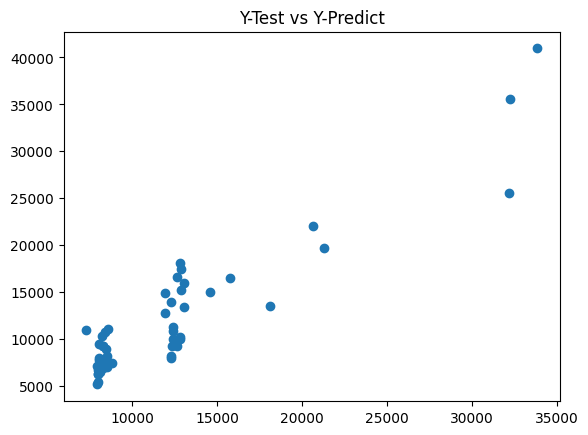

In [87]:
plt.scatter(y_test_pred, y_test)
plt.title('Y-Test vs Y-Predict')
plt.show()

In [86]:
lr_model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     32.17
Date:                Fri, 16 May 2025   Prob (F-statistic):           2.15e-34
Time:                        08:04:23   Log-Likelihood:                -1498.3
No. Observations:                 153   AIC:                             3023.
Df Residuals:                     140   BIC:                             3062.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                4115.5446   2503.408      1.644      0.102    -833.828    9064.918
make(mercedes-benz)  2.283e+04   2615.095      8.731      0.000    1.77e+04     2.8e+04
fuel system(mpfi)    3996.4260    887.495      4.503      0.000    2241.800    5751.052
cylinders(six)       7599.8656   1631.307      4.659      0.000    4374.684    1.08e+04
engine type(ohcv)   -2036.5076   2259.139     -0.901      0.369   -6502.947    2429.932
make(bmw)            7791.3530   2104.073      3.703      0.000    3631.488     1.2e+04
make(jaguar)         1.182e+04   4844.648      2.440      0.016    2241.397    2.14e+04
bore                 5121.6055   3024.319      1.693      0.093    -857.635    1.11e+04
make(porsche)        4227.3905   2802.543      1.508      0.134   -1313.387    9768.168
style(hardtop)       1131.8392   1836.674      0.616      0.539   -2499.364    4763.042
cylinders(five)       593.4990   1948.608      0.305      0.761   -3259.003    4446.001
symboling(3)         3152.2661   1260.881      2.500      0.014     659.437    5645.095
cylinders(twelve)     1.35e+04   7268.918      1.858      0.065    -867.676    2.79e+04
==============================================================================
Omnibus:                       10.158   Durbin-Watson:                   2.366
Prob(Omnibus):                  0.006   Jarque-Bera (JB):               22.759
Skew:                           0.108   Prob(JB):                     1.14e-05
Kurtosis:                       4.877   Cond. No.                         32.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [38]:
df_car_itr_3

,price,make(mercedes-benz),fuel system(mpfi),cylinders(six),engine type(ohcv),make(bmw),make(jaguar),bore,make(porsche),style(hardtop),cylinders(five),symboling(3),cylinders(twelve)
0,13495.0,0,1,0,0,0,0,3.47,0,0,0,1,0
1,16500.0,0,1,0,0,0,0,3.47,0,0,0,1,0
2,16500.0,0,1,1,1,0,0,2.68,0,0,0,0,0
3,13950.0,0,1,0,0,0,0,3.19,0,0,0,0,0
4,17450.0,0,1,0,0,0,0,3.19,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,16845.0,0,1,0,0,0,0,3.78,0,0,0,0,0
201,19045.0,0,1,0,0,0,0,3.78,0,0,0,0,0
202,21485.0,0,1,1,1,0,0,3.58,0,0,0,0,0
203,22470.0,0,0,1,0,0,0,3.01,0,0,0,0,0
